# Compressed Sensing

**Sparse recovery via L1 minimization and 2D image reconstruction via total-variation minimization** — the "single-pixel camera" problem, solved using Moreau's CVXPY backend.

This notebook demonstrates:
- **Part A**: 1D compressed sensing (basis pursuit) — recover a sparse signal from far fewer measurements than its length
- **Part B**: 2D image reconstruction from random projections — recover a 64×64 image by minimizing total variation subject to measurement constraints
- **Part C**: Learning the measurement matrix by differentiating through the TV reconstruction solver via cvxpylayers

In [1]:
import sys
sys.path.insert(0, "..")

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
from scipy import sparse
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import torch
import cvxpy as cp
import moreau
from cvxpylayers.torch import CvxpyLayer

from utils.style import set_moreau_style, set_moreau_dark_style, MOREAU_COLORS

set_moreau_style()
torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


## Part A: Compressed Sensing (Sparse Recovery)

We observe a sparse signal $x^\star \in \mathbb{R}^n$ through $m \ll n$ random linear measurements:

$$y = \Phi \, x^\star + \eta$$

where $\Phi \in \mathbb{R}^{m \times n}$ is a random Gaussian measurement matrix and $\eta$ is small noise. The goal is to recover $x^\star$ from the compressed observations $y$.

In [2]:
# Signal parameters
n = 2000      # signal length
k = 15        # number of non-zero components
m_meas = 600  # number of measurements (m << n)

# Generate sparse ground truth signal
x_true = np.zeros(n, dtype=np.float64)
support = np.random.choice(n, size=k, replace=False)
x_true[support] = np.random.randn(k) * 3.0

# Random Gaussian measurement matrix
Phi = np.random.randn(m_meas, n).astype(np.float64) / np.sqrt(m_meas)

# Noisy measurements
noise_std = 0.01
y = Phi @ x_true + noise_std * np.random.randn(m_meas)

print(f"Signal length n = {n}, sparsity k = {k}")
print(f"Measurements m = {m_meas} ({m_meas/n:.0%} of n)")
print(f"||x_true||_0 = {np.count_nonzero(x_true)}, ||x_true||_1 = {np.abs(x_true).sum():.2f}")
print(f"||y||_2 = {np.linalg.norm(y):.4f}, noise std = {noise_std}")

Signal length n = 2000, sparsity k = 15
Measurements m = 600 (30% of n)
||x_true||_0 = 15, ||x_true||_1 = 33.98
||y||_2 = 10.9320, noise std = 0.01


## Basis Pursuit (L1 Minimization)

We recover the sparse signal by solving the **basis pursuit** problem:

$$\min_{x} \|x\|_1 \quad \text{s.t.} \quad \Phi x = y$$

L1 minimization promotes sparsity: among all signals consistent with the measurements, it finds the one with the smallest sum of absolute values — which, for sufficiently sparse signals, is exactly $x^\star$.

Status: optimal
||x_true||_1 = 33.9835
||x_recovered||_1 = 37.9387
Recovery error: ||x_recovered - x_true||_2 / ||x_true||_2 = 2.2873e-02


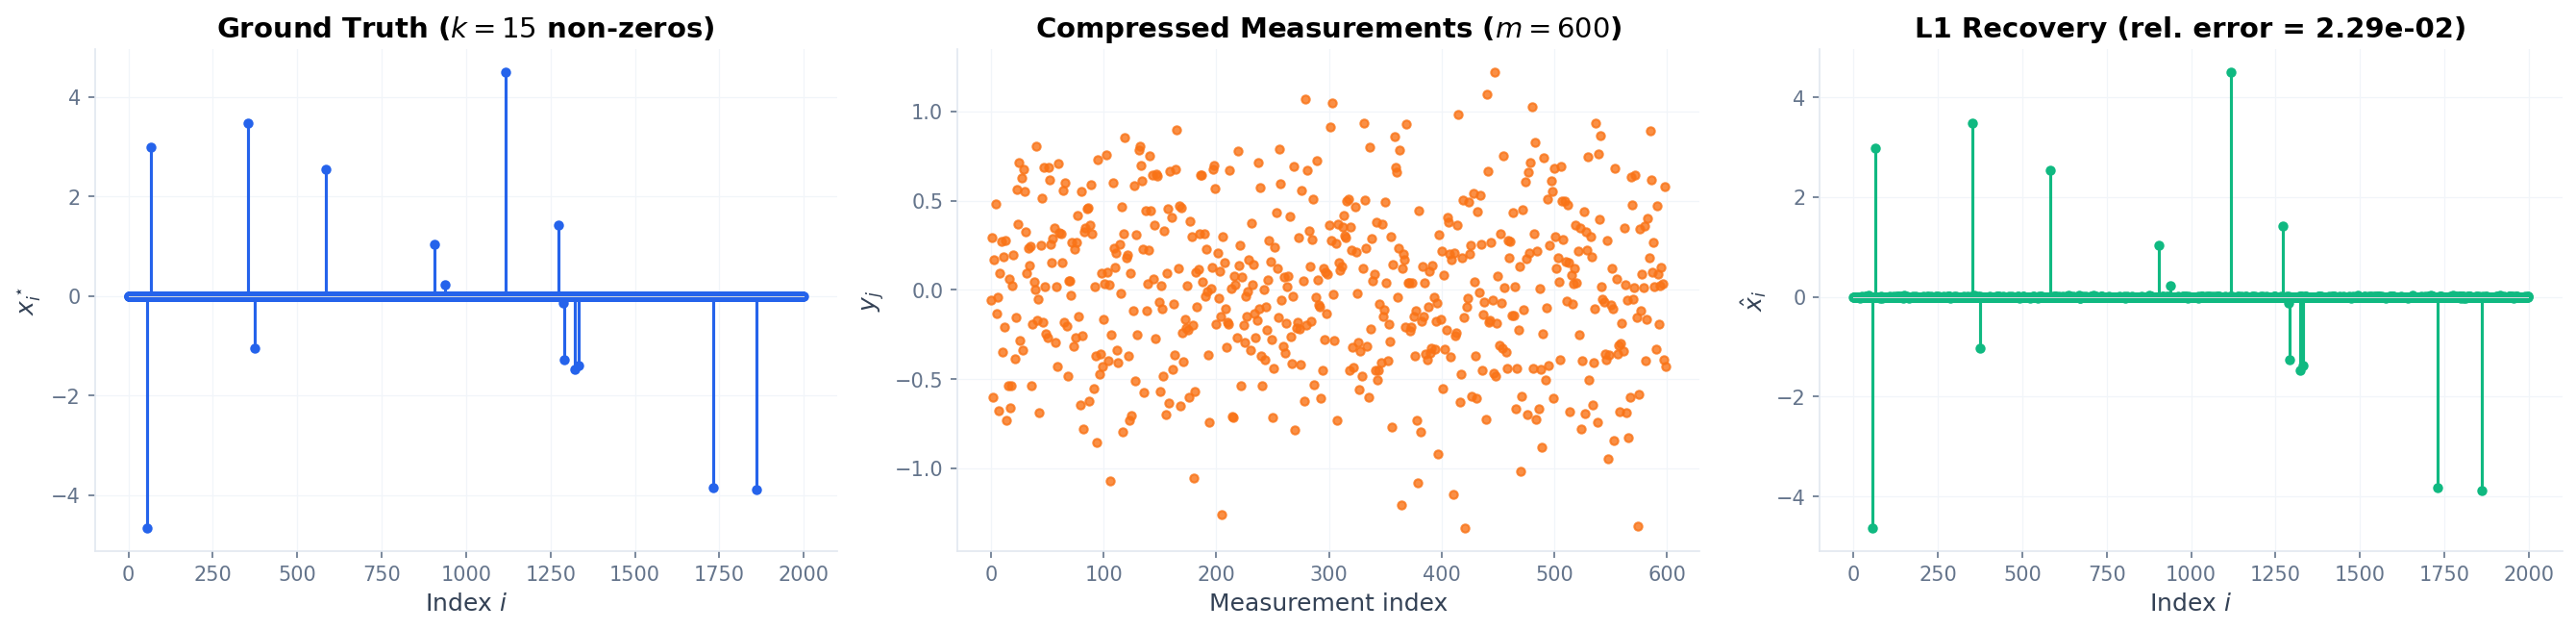

In [3]:
x = cp.Variable(n)
prob = cp.Problem(cp.Minimize(cp.norm1(x)), [Phi @ x == y])
prob.solve(solver=cp.MOREAU)

x_recovered = x.value

print(f"Status: {prob.status}")
print(f"||x_true||_1 = {np.abs(x_true).sum():.4f}")
print(f"||x_recovered||_1 = {np.abs(x_recovered).sum():.4f}")
print(f"Recovery error: ||x_recovered - x_true||_2 / ||x_true||_2 = {np.linalg.norm(x_recovered - x_true) / np.linalg.norm(x_true):.4e}")

# --- Triptych: ground truth / measurements / recovery ---
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

# Panel 1: Ground truth
ax = axes[0]
markerline, stemlines, baseline = ax.stem(np.arange(n), x_true, linefmt='-', markerfmt='o', basefmt='k-')
plt.setp(stemlines, color=MOREAU_COLORS['primary'], linewidth=1.5)
plt.setp(markerline, color=MOREAU_COLORS['primary'], markersize=4)
plt.setp(baseline, linewidth=0.5, color=MOREAU_COLORS['neutral_light'])
ax.set_xlabel('Index $i$')
ax.set_ylabel('$x^\\star_i$')
ax.set_title(f'Ground Truth ($k={k}$ non-zeros)')

# Panel 2: Measurements
ax = axes[1]
ax.plot(np.arange(m_meas), y, 'o', color=MOREAU_COLORS['accent'], markersize=4, alpha=0.8)
ax.set_xlabel('Measurement index')
ax.set_ylabel('$y_j$')
ax.set_title(f'Compressed Measurements ($m={m_meas}$)')

# Panel 3: Recovered signal
ax = axes[2]
markerline, stemlines, baseline = ax.stem(np.arange(n), x_recovered, linefmt='-', markerfmt='o', basefmt='k-')
plt.setp(stemlines, color=MOREAU_COLORS['success'], linewidth=1.5)
plt.setp(markerline, color=MOREAU_COLORS['success'], markersize=4)
plt.setp(baseline, linewidth=0.5, color=MOREAU_COLORS['neutral_light'])
ax.set_xlabel('Index $i$')
ax.set_ylabel('$\\hat{x}_i$')
rel_err = np.linalg.norm(x_recovered - x_true) / np.linalg.norm(x_true)
ax.set_title(f'L1 Recovery (rel. error = {rel_err:.2e})')

plt.tight_layout()
plt.show()

## Part B: 2D Image Reconstruction (Single-Pixel Camera)

A **single-pixel camera** captures an image by taking $m$ random linear projections of the scene — far fewer than the number of pixels $n = H \times W$. If the image is piecewise-smooth, we can reconstruct it by minimizing **total variation**:

$$\min_{x} \; \mathrm{TV}(x) \quad \text{s.t.} \quad \Phi \, x = y$$

where $\Phi \in \mathbb{R}^{m \times n}$ is the random measurement matrix and $y = \Phi \, x^\star + \eta$ are noisy compressed observations.

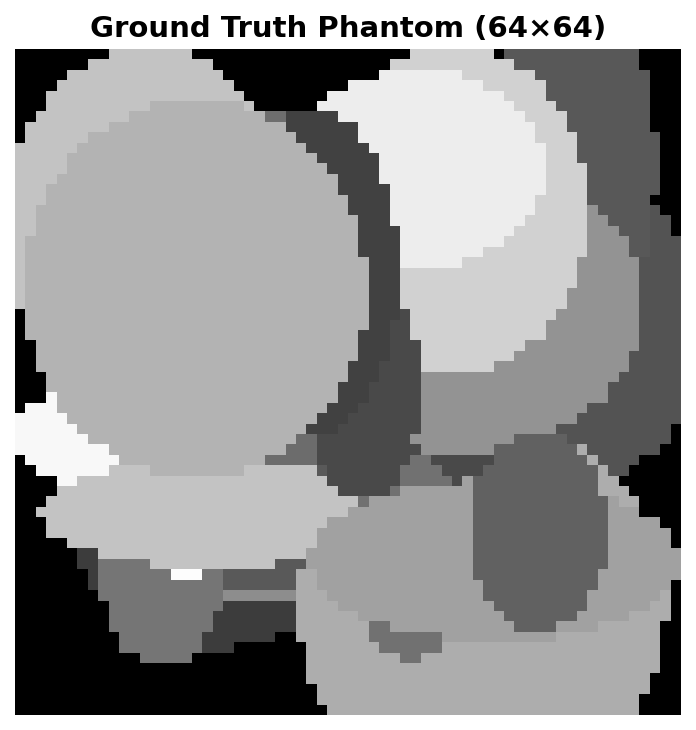

Image size: 64×64 = 4096 pixels
Pixel range: [0.00, 0.99]


In [4]:
def make_phantom(H, W, n_ellipses=25, seed=0):
    """Generate a phantom image with overlapping filled ellipses."""
    rng = np.random.RandomState(seed)
    img = np.zeros((H, W), dtype=np.float64)
    yy, xx = np.mgrid[:H, :W].astype(np.float64)

    for _ in range(n_ellipses):
        cy, cx = rng.uniform(0.15, 0.85, size=2) * [H, W]
        ry, rx = rng.uniform(0.08, 0.30, size=2) * [H, W]
        intensity = rng.uniform(0.2, 1.0)
        mask = ((yy - cy) / ry) ** 2 + ((xx - cx) / rx) ** 2 <= 1.0
        img[mask] = intensity

    return img

H, W = 64, 64
n_pixels = H * W
phantom = make_phantom(H, W, seed=42)

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(phantom, cmap='gray', vmin=0, vmax=1)
ax.set_title(f'Ground Truth Phantom ({H}×{W})')
ax.axis('off')
plt.tight_layout()
plt.show()

print(f"Image size: {H}×{W} = {n_pixels} pixels")
print(f"Pixel range: [{phantom.min():.2f}, {phantom.max():.2f}]")

### Total Variation Minimization

The 2D **anisotropic total variation** decomposes into horizontal and vertical finite differences:

$$\mathrm{TV}(x) = \|D_h x\|_1 + \|D_v x\|_1$$

where $D_h$ and $D_v$ are the horizontal and vertical difference operators. We build these as sparse matrices and let CVXPY + Moreau handle the LP reformulation automatically.

Status: optimal
PSNR: 44.8 dB


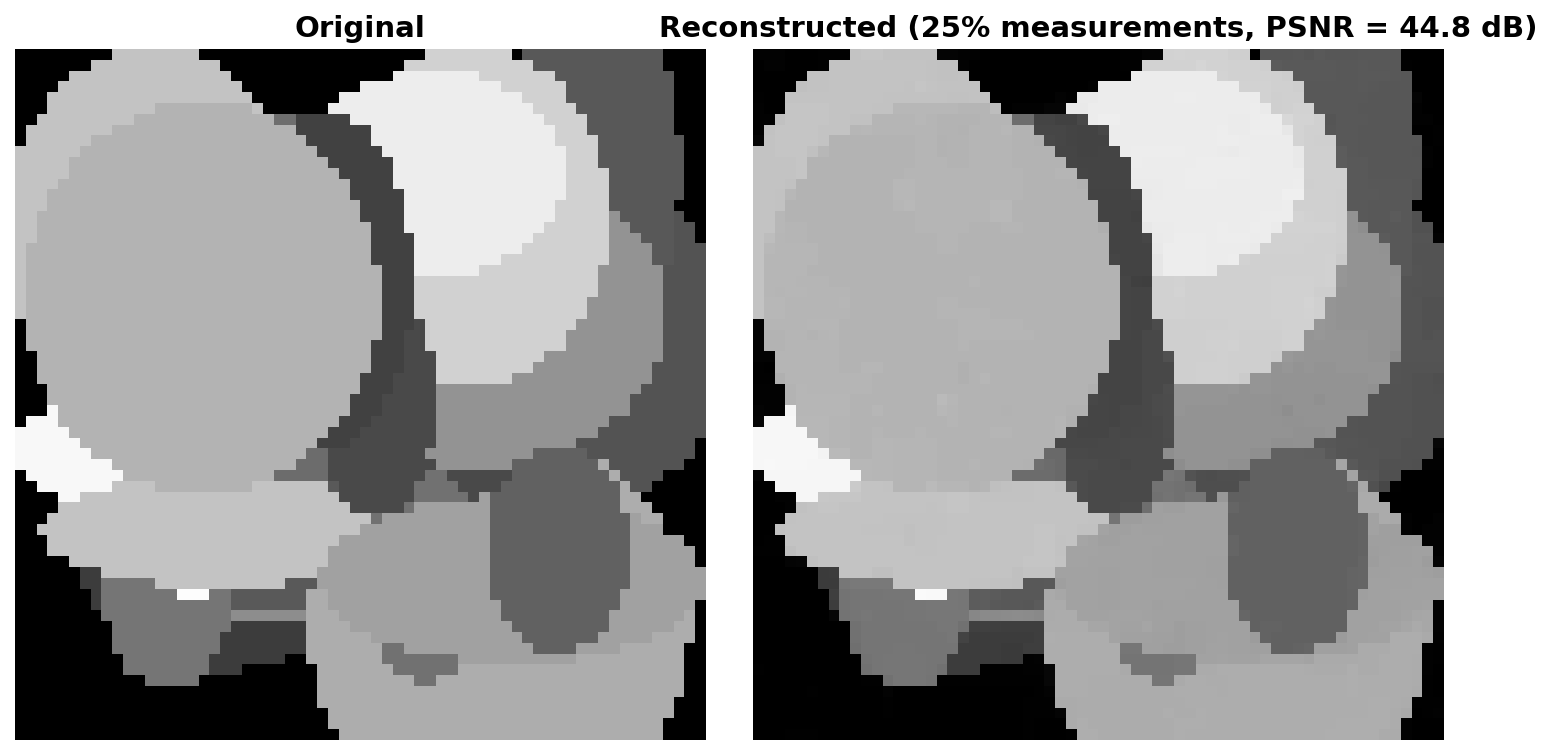

In [5]:
def build_diff_operators(H, W):
    """Build horizontal and vertical finite-difference operators for an H×W image."""
    n_pixels = H * W
    # D_h: horizontal differences, shape (H*(W-1), H*W)
    n_h = H * (W - 1)
    rows_h = np.arange(n_h)
    i_h = rows_h // (W - 1)
    j_h = rows_h % (W - 1)
    col_left = i_h * W + j_h
    col_right = col_left + 1
    D_h = sparse.csr_array(
        (np.concatenate([-np.ones(n_h), np.ones(n_h)]),
         (np.concatenate([rows_h, rows_h]), np.concatenate([col_left, col_right]))),
        shape=(n_h, n_pixels), dtype=np.float64,
    )
    # D_v: vertical differences, shape ((H-1)*W, H*W)
    n_v = (H - 1) * W
    rows_v = np.arange(n_v)
    col_top = (rows_v // W) * W + rows_v % W
    col_bot = col_top + W
    D_v = sparse.csr_array(
        (np.concatenate([-np.ones(n_v), np.ones(n_v)]),
         (np.concatenate([rows_v, rows_v]), np.concatenate([col_top, col_bot]))),
        shape=(n_v, n_pixels), dtype=np.float64,
    )
    return D_h, D_v


D_h, D_v = build_diff_operators(H, W)

# --- Solve at 25% compression ---
compression = 0.25
m_img = int(compression * n_pixels)
noise_std_img = 0.005

rng_phi = np.random.RandomState(123)
Phi_img = rng_phi.randn(m_img, n_pixels).astype(np.float64) / np.sqrt(m_img)
y_img = Phi_img @ phantom.ravel() + noise_std_img * np.random.RandomState(999).randn(m_img)

x_img = cp.Variable(n_pixels)
tv = cp.norm1(D_h @ x_img) + cp.norm1(D_v @ x_img)
prob_img = cp.Problem(cp.Minimize(tv), [Phi_img @ x_img == y_img])
prob_img.solve(solver=cp.MOREAU)

x_rec = x_img.value.reshape(H, W)
mse_img = np.mean((x_rec - phantom) ** 2)
psnr_img = 10 * np.log10(1.0 / mse_img) if mse_img > 0 else float('inf')

print(f"Status: {prob_img.status}")
print(f"PSNR: {psnr_img:.1f} dB")

# --- Side-by-side: original vs reconstructed ---
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(phantom, cmap='gray', vmin=0, vmax=1)
axes[0].set_title('Original')
axes[0].axis('off')
axes[1].imshow(x_rec, cmap='gray', vmin=0, vmax=1)
axes[1].set_title(f'Reconstructed ({compression:.0%} measurements, PSNR = {psnr_img:.1f} dB)')
axes[1].axis('off')
plt.tight_layout()
plt.show()

### Compression Ratio Sweep

How many measurements do we actually need? We vary the compression ratio $m/n$ from 5% to 50%. Each ratio gives a different-sized LP (the measurement matrix $\Phi$ changes dimensions), so we solve them sequentially.

  ratio=5%, m=204, PSNR=16.9 dB, status=optimal


  ratio=10%, m=409, PSNR=19.8 dB, status=optimal


  ratio=15%, m=614, PSNR=26.6 dB, status=optimal


  ratio=20%, m=819, PSNR=38.3 dB, status=optimal


  ratio=30%, m=1228, PSNR=45.6 dB, status=optimal


  ratio=50%, m=2048, PSNR=45.3 dB, status=optimal


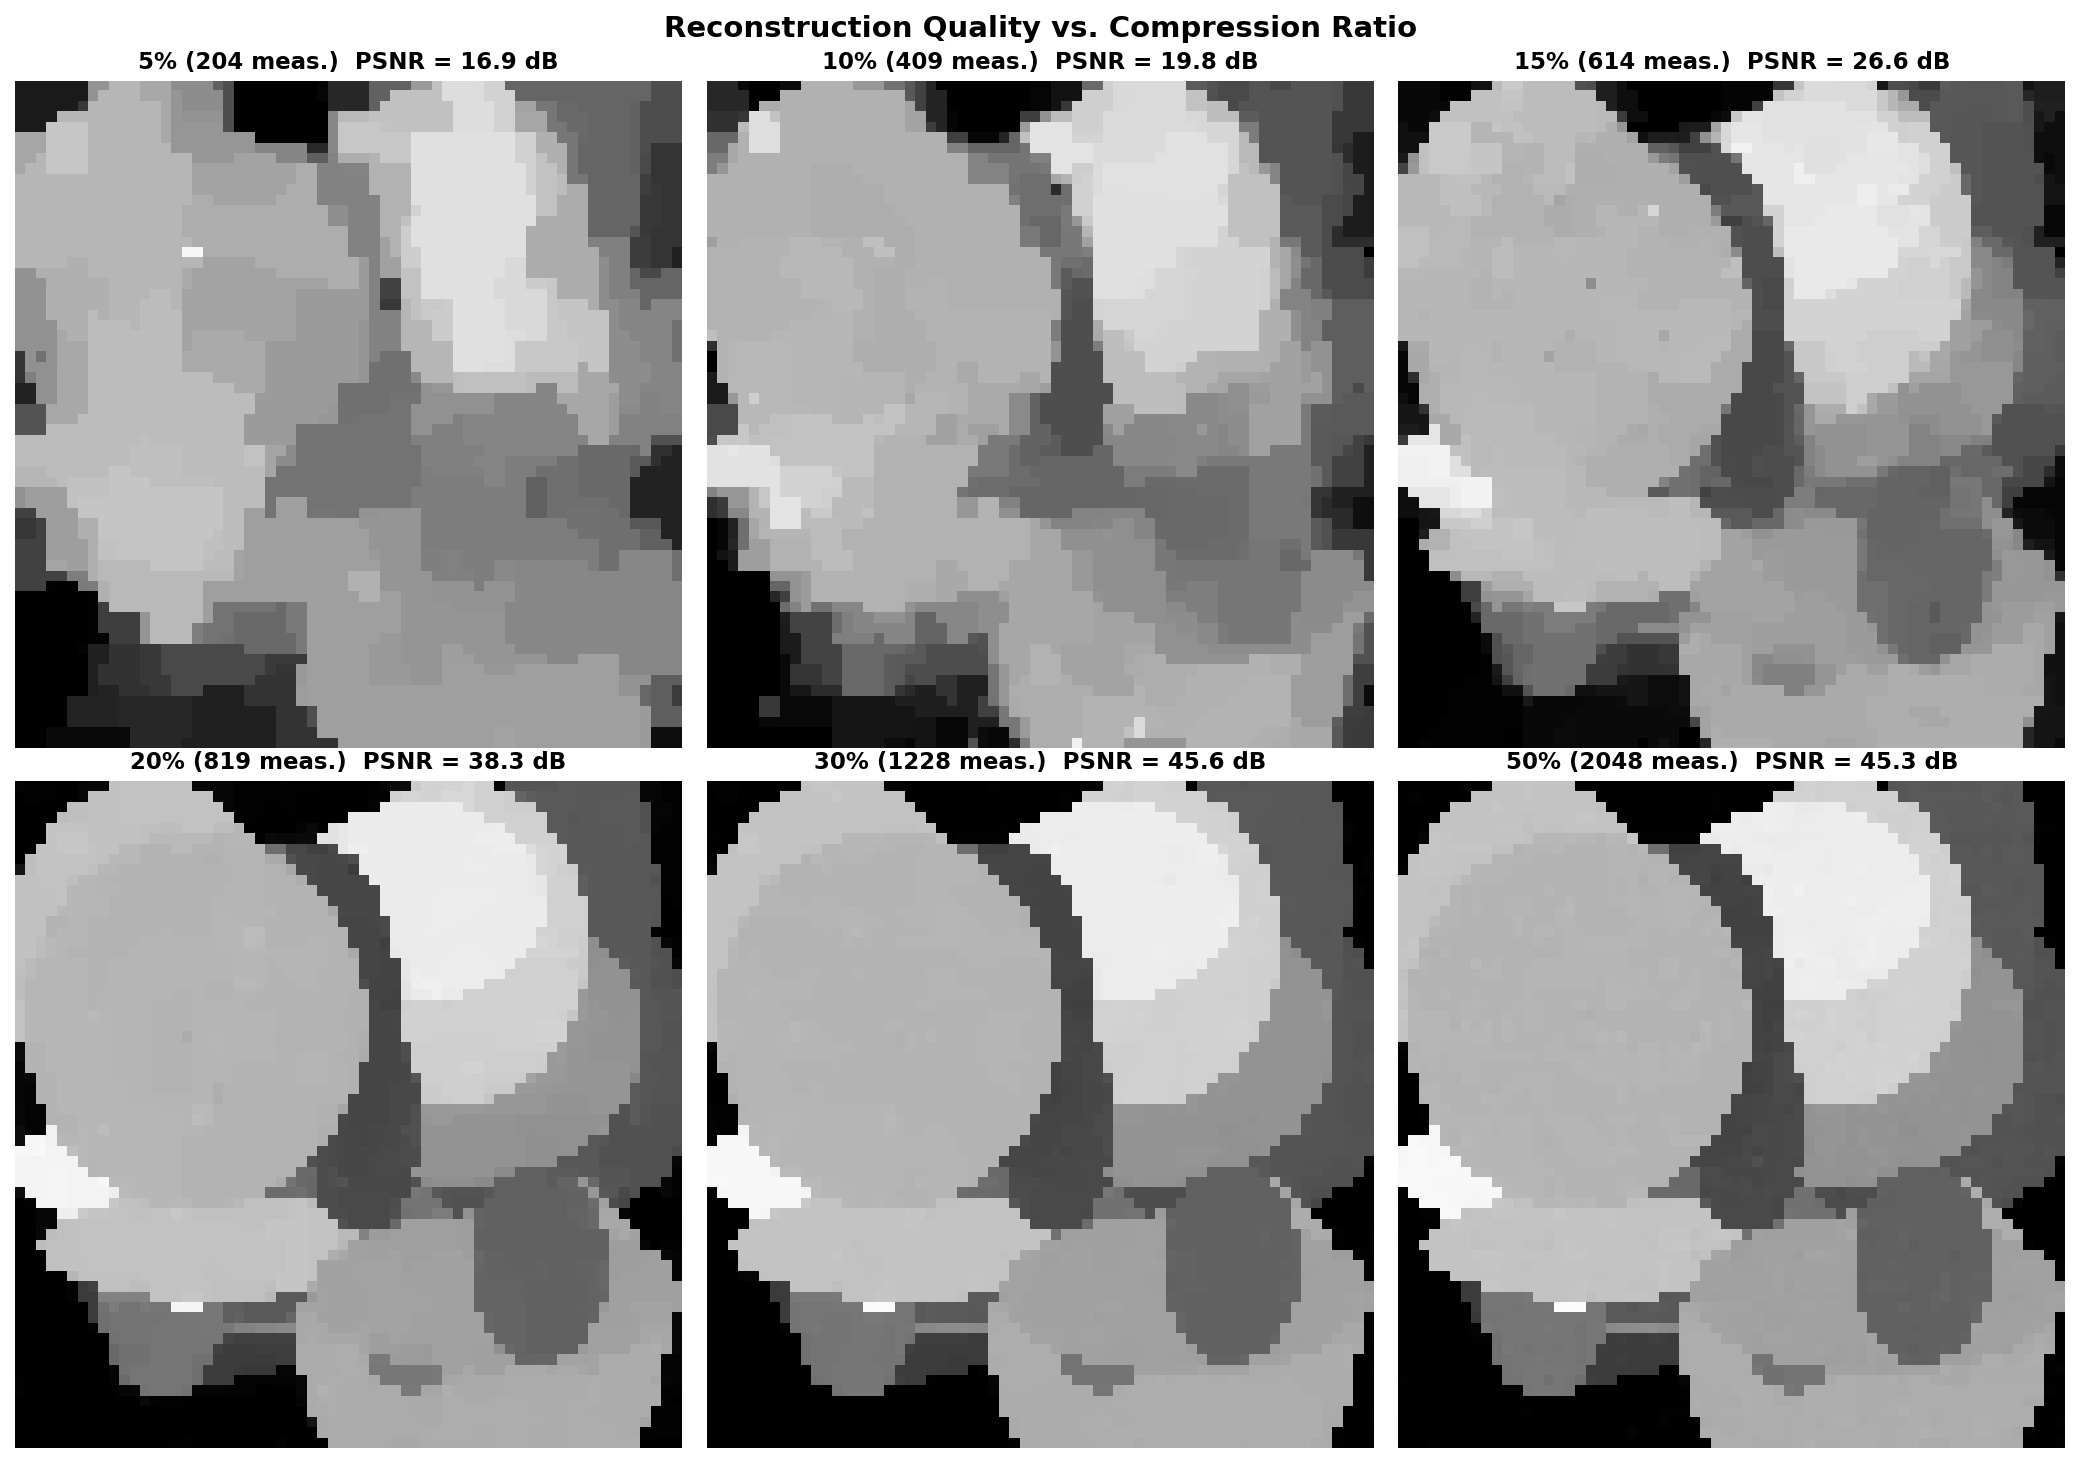

In [6]:
ratios = [0.05, 0.10, 0.15, 0.20, 0.30, 0.50]
x_flat = phantom.ravel()
sweep_results = []

for ratio in ratios:
    m_sweep = int(ratio * n_pixels)
    rng_sweep = np.random.RandomState(123)
    Phi_sweep = rng_sweep.randn(m_sweep, n_pixels).astype(np.float64) / np.sqrt(m_sweep)
    y_sweep = Phi_sweep @ x_flat + noise_std_img * np.random.RandomState(999).randn(m_sweep)

    x_s = cp.Variable(n_pixels)
    tv_s = cp.norm1(D_h @ x_s) + cp.norm1(D_v @ x_s)
    prob_s = cp.Problem(cp.Minimize(tv_s), [Phi_sweep @ x_s == y_sweep])
    prob_s.solve(solver=cp.MOREAU)

    x_rec_s = x_s.value.reshape(H, W)
    mse_s = np.mean((x_rec_s - phantom) ** 2)
    psnr_s = 10 * np.log10(1.0 / mse_s) if mse_s > 0 else float('inf')
    sweep_results.append((ratio, m_sweep, x_rec_s, psnr_s))
    print(f"  ratio={ratio:.0%}, m={m_sweep}, PSNR={psnr_s:.1f} dB, status={prob_s.status}")

# --- 2×3 grid of reconstructions ---
fig, axes = plt.subplots(2, 3, figsize=(14, 10))

for idx, (ratio, m_sweep, x_s, psnr_s) in enumerate(sweep_results):
    ax = axes[idx // 3, idx % 3]
    ax.imshow(x_s, cmap='gray', vmin=0, vmax=1)
    ax.set_title(f'{ratio:.0%} ({m_sweep} meas.)  PSNR = {psnr_s:.1f} dB', fontsize=11)
    ax.axis('off')

plt.suptitle('Reconstruction Quality vs. Compression Ratio', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig('../assets/compressed_sensing.png', bbox_inches='tight', facecolor='white')
plt.show()

## Part C: Learning the Measurement Matrix

Random Gaussian measurement matrices satisfy the **restricted isometry property** (RIP) and work universally for any sparse signal. But can we do *better* for a **known image distribution**?

We formulate a **bilevel optimization** problem:

- **Outer problem**: minimize the reconstruction MSE over training images by updating Φ
- **Inner problem**: for each image, solve the TV minimization to reconstruct from measurements $y = \Phi x$

$$\min_{\Phi} \;\; \frac{1}{|\mathcal{T}|} \sum_{x \in \mathcal{T}} \| x^*(\Phi, y) - x \|^2 \qquad \text{s.t.} \quad x^*(\Phi, y) = \arg\min_z \; \mathrm{TV}(z) + \tfrac{\varepsilon}{2}\|z\|^2 \quad \text{s.t.} \;\; \Phi z = y$$

Note that Φ appears in **two places**: (1) in the constraint matrix of the inner LP (differentiated via KKT implicit differentiation), and (2) in the measurement computation $y = \Phi x$ (differentiated via standard autograd). Both gradient paths accumulate into $\nabla_\Phi \mathcal{L}$.

In [7]:
# --- Data: 32×32 phantoms for training tractability ---
H_c, W_c = 32, 32
n_c = H_c * W_c  # 1024 pixels

n_train, n_test = 100, 5
train_imgs = [make_phantom(H_c, W_c, seed=i) for i in range(n_train)]
test_imgs = [make_phantom(H_c, W_c, seed=1000 + i) for i in range(n_test)]

# Compression ratio: 10% — low enough that random Φ leaves room for improvement
compression_c = 0.10
m_c = int(compression_c * n_c)  # ~102 measurements

print(f"Image size: {H_c}×{W_c} = {n_c} pixels")
print(f"Measurements: m = {m_c} ({compression_c:.0%} compression)")
print(f"Training images: {n_train}, test images: {n_test}")

# --- Build finite-difference operators for 32×32 ---
D_h_c, D_v_c = build_diff_operators(H_c, W_c)

# --- Parametric CVXPY problem ---
x_c = cp.Variable(n_c)
Phi_param = cp.Parameter((m_c, n_c))     # measurement matrix (learnable)
y_param = cp.Parameter(m_c)               # measurements (computed per-image)

eps_reg = 0.01  # small quadratic regularizer for stable KKT implicit diff
tv_c = cp.norm1(D_h_c @ x_c) + cp.norm1(D_v_c @ x_c) + (eps_reg / 2) * cp.sum_squares(x_c)

prob_c = cp.Problem(cp.Minimize(tv_c), [Phi_param @ x_c == y_param])

print(f"DPP-compliant: {prob_c.is_dpp()}")

# Wrap as a differentiable layer
# cvxpylayers auto-selects CUDA when input tensors are on GPU;
# set direct_solve_method explicitly to skip first-solve auto-tuning
tv_layer = CvxpyLayer(
    prob_c, parameters=[Phi_param, y_param], variables=[x_c],
    solver="MOREAU",
    solver_args={"ipm_settings": moreau.IPMSettings(direct_solve_method="cudss")},
)

# --- Verify: forward + backward on one image ---
Phi_test = torch.randn(m_c, n_c, dtype=torch.float64, device=device) / np.sqrt(m_c)
Phi_test.requires_grad_(True)
x_test = torch.tensor(train_imgs[0].ravel(), dtype=torch.float64, device=device)
y_test = Phi_test @ x_test

x_rec_test, = tv_layer(Phi_test, y_test)
loss_test = (x_rec_test - x_test).pow(2).mean()
loss_test.backward()

print(f"Verification — loss: {loss_test.item():.4f}, "
      f"Φ grad finite: {torch.isfinite(Phi_test.grad).all().item()}, "
      f"Φ grad norm: {Phi_test.grad.norm().item():.4f}")

Image size: 32×32 = 1024 pixels
Measurements: m = 102 (10% compression)
Training images: 100, test images: 5
DPP-compliant: True


Verification — loss: 0.0169, Φ grad finite: True, Φ grad norm: 0.2989


In [8]:
# --- Baseline: random Gaussian Φ ---
def reconstruct(Phi_np, x_true_np, layer):
    """Reconstruct a single image using the TV layer (no grad)."""
    Phi_t = torch.tensor(Phi_np, dtype=torch.float64, device=device)
    x_t = torch.tensor(x_true_np.ravel(), dtype=torch.float64, device=device)
    y_t = Phi_t @ x_t
    with torch.no_grad():
        x_rec, = layer(Phi_t, y_t)
    return x_rec.cpu().numpy()


def compute_psnr(x_rec, x_true):
    """Compute PSNR (dB) between reconstructed and ground truth images."""
    mse = np.mean((x_rec - x_true.ravel()) ** 2)
    return 10 * np.log10(1.0 / mse) if mse > 0 else float('inf')


# Random Gaussian baseline
rng_c = np.random.RandomState(123)
Phi_random = rng_c.randn(m_c, n_c).astype(np.float64) / np.sqrt(m_c)

print("Random Φ — test set PSNR:")
random_psnrs = []
for i, img in enumerate(test_imgs):
    x_rec_rand = reconstruct(Phi_random, img, tv_layer)
    psnr = compute_psnr(x_rec_rand, img)
    random_psnrs.append(psnr)
    print(f"  Image {i}: {psnr:.1f} dB")
print(f"  Mean: {np.mean(random_psnrs):.1f} dB")

Random Φ — test set PSNR:
  Image 0: 15.5 dB
  Image 1: 15.0 dB
  Image 2: 18.1 dB


  Image 3: 16.5 dB


  Image 4: 17.2 dB
  Mean: 16.5 dB


### Training the Measurement Matrix

Each training step:
1. Pick a training image $x$
2. Compute measurements $y = \Phi x$
3. Solve the TV reconstruction $x^*(\Phi, y)$
4. Compute MSE loss $\|x^* - x\|^2$
5. Backpropagate through the solver to get $\nabla_\Phi \mathcal{L}$
6. Update Φ with Adam, then normalize rows

Each forward+backward solves a ~3000-variable conic program; the backward pass computes the gradient via a single linear system solve (implicit differentiation of the KKT conditions).

In [9]:
# --- Initialize Φ (same distribution as random baseline) ---
Phi_learned = torch.randn(m_c, n_c, dtype=torch.float64, device=device) / np.sqrt(m_c)
Phi_learned = torch.nn.Parameter(Phi_learned)

optimizer = torch.optim.Adam([Phi_learned], lr=0.01)

# Row norm target: sqrt(n/m) matches expected norm of random Gaussian rows
row_norm_target = np.sqrt(n_c / m_c)

n_steps = 300
train_tensors = [torch.tensor(img.ravel(), dtype=torch.float64, device=device) for img in train_imgs]
val_img = torch.tensor(test_imgs[0].ravel(), dtype=torch.float64, device=device)

losses_c = []
val_psnrs = []
val_steps = []

print(f"Training Φ for {n_steps} steps (lr=0.01, Adam)...")
for step in range(n_steps):
    optimizer.zero_grad()

    # Cycle through training images
    x_train = train_tensors[step % n_train]
    y_train = Phi_learned @ x_train

    x_rec_train, = tv_layer(Phi_learned, y_train)
    loss = (x_rec_train - x_train).pow(2).mean()
    loss.backward()

    optimizer.step()

    # Normalize rows to prevent scale drift
    with torch.no_grad():
        norms = Phi_learned.data.norm(dim=1, keepdim=True)
        Phi_learned.data.mul_(row_norm_target / norms)

    losses_c.append(loss.item())

    # Validation PSNR every 10 steps
    if step % 10 == 0 or step == n_steps - 1:
        y_val = Phi_learned @ val_img
        with torch.no_grad():
            x_rec_val, = tv_layer(Phi_learned, y_val)
        mse_val = (x_rec_val - val_img).pow(2).mean().item()
        psnr_val = 10 * np.log10(1.0 / mse_val) if mse_val > 0 else float('inf')
        val_psnrs.append(psnr_val)
        val_steps.append(step)

    if (step + 1) % 50 == 0:
        print(f"  Step {step+1:3d}: loss={loss.item():.6f}, val PSNR={val_psnrs[-1]:.1f} dB")

print("Done.")

Training Φ for 300 steps (lr=0.01, Adam)...


  Step  50: loss=0.011907, val PSNR=15.9 dB


  Step 100: loss=0.026776, val PSNR=16.2 dB


  Step 150: loss=0.009165, val PSNR=16.4 dB


  Step 200: loss=0.014640, val PSNR=16.4 dB


  Step 250: loss=0.008896, val PSNR=17.0 dB


  Step 300: loss=0.020334, val PSNR=18.2 dB
Done.


In [10]:
# --- Evaluate learned Φ on all test images ---
Phi_learned_np = Phi_learned.detach().cpu().numpy()

print("Learned Φ — test set PSNR:")
learned_psnrs = []
random_recs = []
learned_recs = []
for i, img in enumerate(test_imgs):
    x_rec_rand = reconstruct(Phi_random, img, tv_layer)
    x_rec_learn = reconstruct(Phi_learned_np, img, tv_layer)
    psnr_r = compute_psnr(x_rec_rand, img)
    psnr_l = compute_psnr(x_rec_learn, img)
    learned_psnrs.append(psnr_l)
    random_recs.append(x_rec_rand.reshape(H_c, W_c))
    learned_recs.append(x_rec_learn.reshape(H_c, W_c))
    print(f"  Image {i}: random={psnr_r:.1f} dB → learned={psnr_l:.1f} dB  (Δ={psnr_l - psnr_r:+.1f} dB)")

print(f"\n  Mean: random={np.mean(random_psnrs):.1f} dB → learned={np.mean(learned_psnrs):.1f} dB  "
      f"(Δ={np.mean(learned_psnrs) - np.mean(random_psnrs):+.1f} dB)")

Learned Φ — test set PSNR:
  Image 0: random=15.5 dB → learned=18.2 dB  (Δ=+2.7 dB)


  Image 1: random=15.0 dB → learned=16.7 dB  (Δ=+1.7 dB)
  Image 2: random=18.1 dB → learned=19.2 dB  (Δ=+1.1 dB)
  Image 3: random=16.5 dB → learned=20.0 dB  (Δ=+3.4 dB)


  Image 4: random=17.2 dB → learned=18.2 dB  (Δ=+1.0 dB)

  Mean: random=16.5 dB → learned=18.4 dB  (Δ=+2.0 dB)


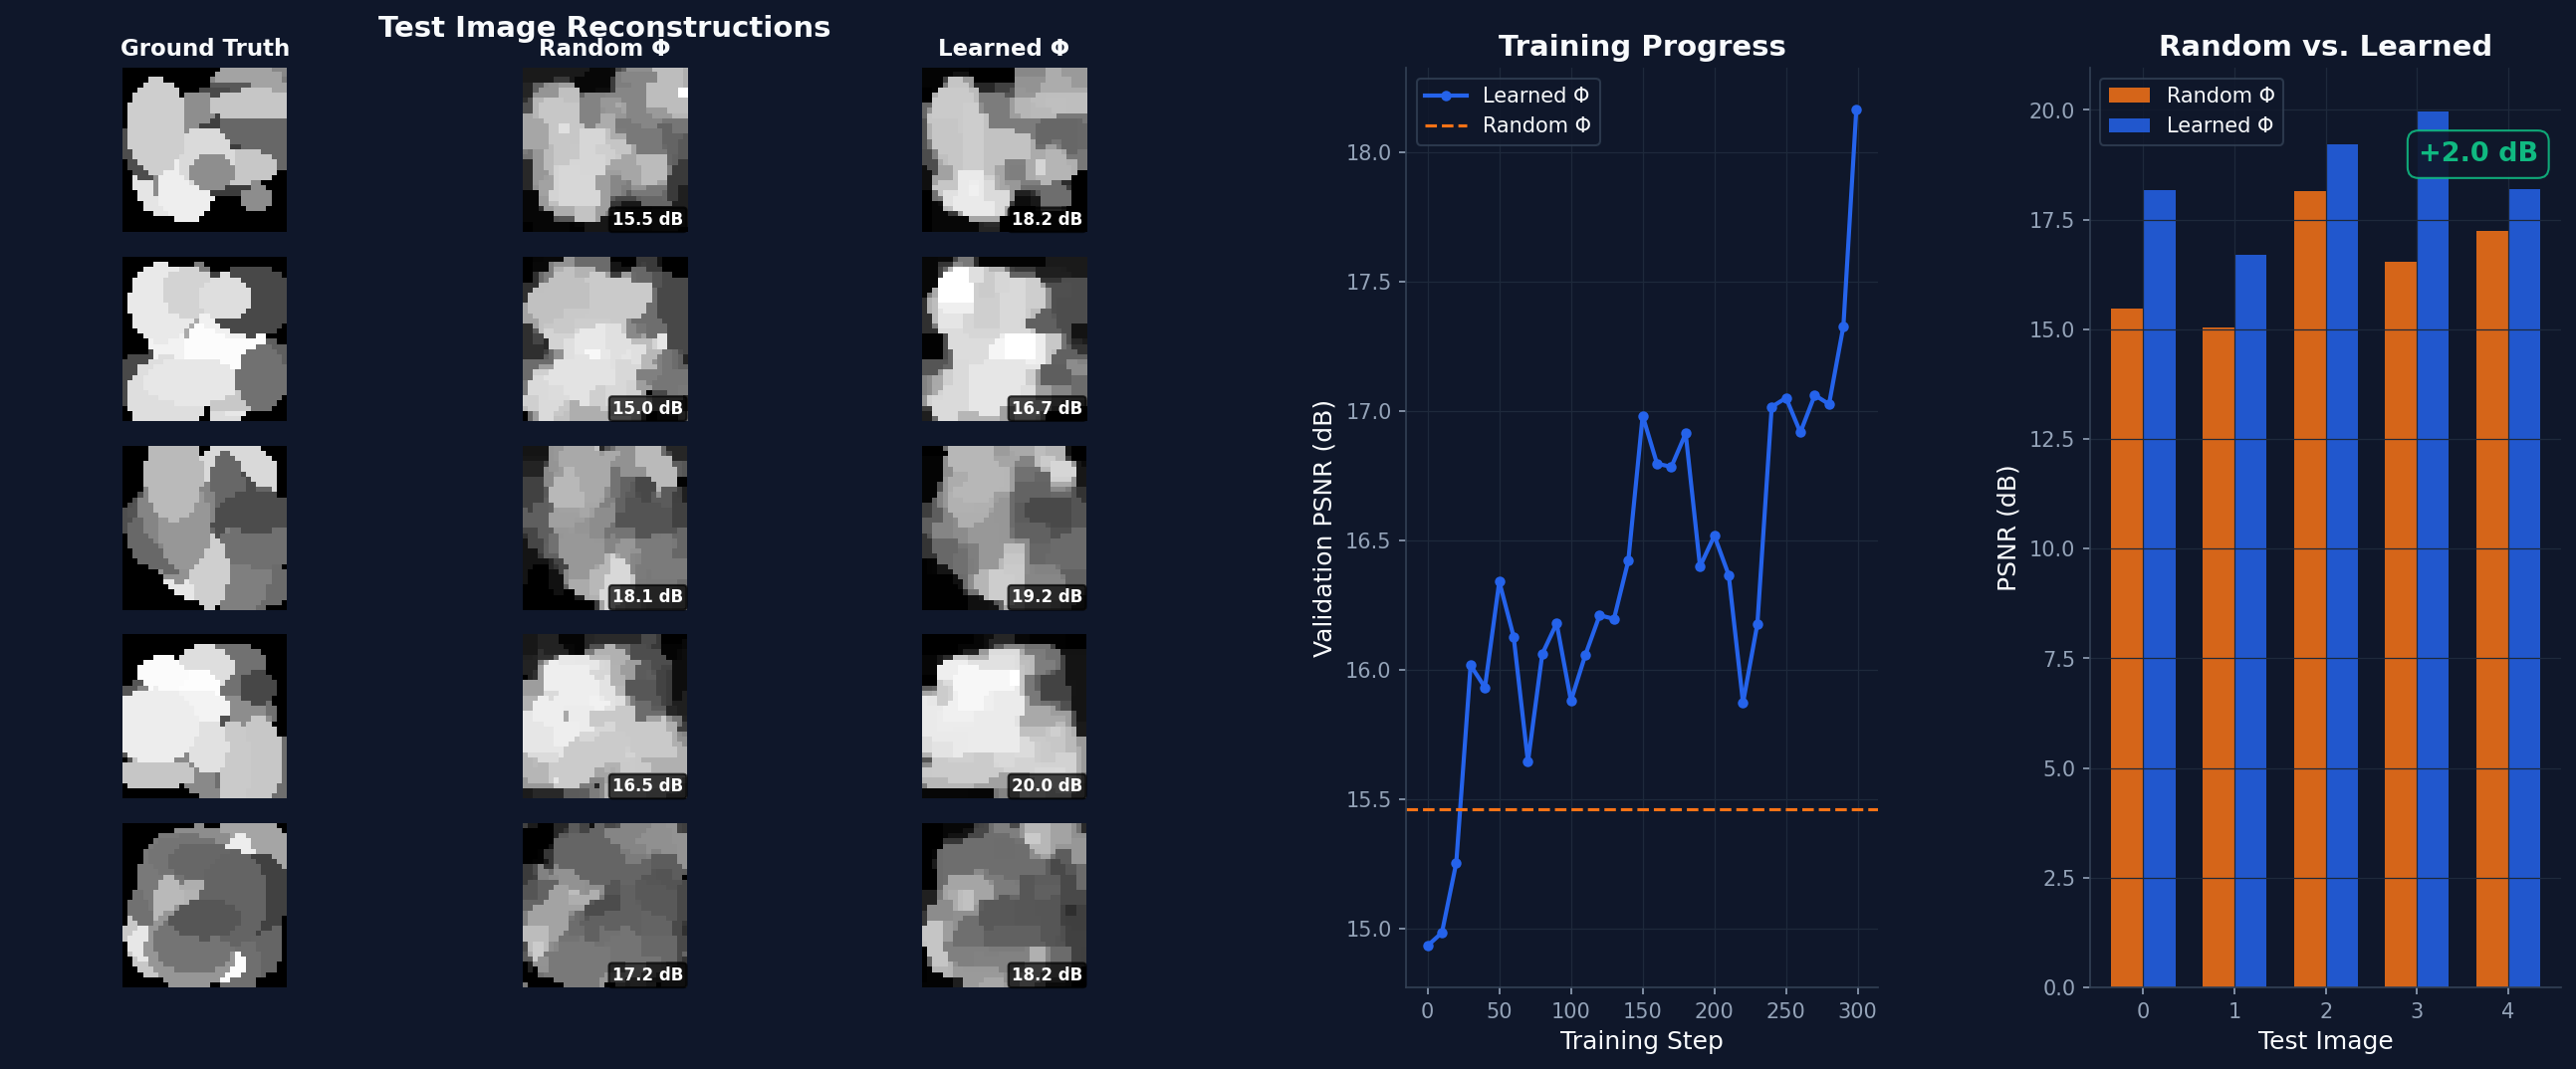

Saved hero image to ../assets/compressed_sensing.png


In [11]:
# --- Hero visualization (dark style, 3 panels) ---
set_moreau_dark_style()

fig = plt.figure(figsize=(22, 8))
gs = gridspec.GridSpec(1, 3, width_ratios=[2.5, 1, 1], wspace=0.3)

# --- Panel 1: Image comparison grid (N_test × 3) ---
ax_grid = fig.add_subplot(gs[0])
ax_grid.set_axis_off()
ax_grid.set_title('Test Image Reconstructions', fontsize=14, fontweight='bold', pad=15)

n_show = min(n_test, 5)
inner_gs = gridspec.GridSpecFromSubplotSpec(n_show, 3, subplot_spec=gs[0], wspace=0.05, hspace=0.15)

col_titles = ['Ground Truth', 'Random Φ', 'Learned Φ']
for j, title in enumerate(col_titles):
    ax_t = fig.add_subplot(inner_gs[0, j])
    ax_t.set_title(title, fontsize=11, fontweight='bold', color=MOREAU_COLORS['text'], pad=6)
    ax_t.set_axis_off()

for i in range(n_show):
    imgs_row = [test_imgs[i], random_recs[i], learned_recs[i]]
    psnrs_row = [None, random_psnrs[i], learned_psnrs[i]]
    for j, (img_show, psnr_show) in enumerate(zip(imgs_row, psnrs_row)):
        ax = fig.add_subplot(inner_gs[i, j])
        ax.imshow(img_show, cmap='gray', vmin=0, vmax=1)
        ax.set_axis_off()
        if psnr_show is not None:
            ax.text(0.98, 0.02, f'{psnr_show:.1f} dB', transform=ax.transAxes,
                    ha='right', va='bottom', fontsize=8, fontweight='bold',
                    color='white', bbox=dict(boxstyle='round,pad=0.2',
                    facecolor='black', alpha=0.7))

# --- Panel 2: Validation PSNR curve ---
ax_curve = fig.add_subplot(gs[1])
ax_curve.plot(val_steps, val_psnrs, '-o', color=MOREAU_COLORS['primary'],
              linewidth=2, markersize=4, label='Learned Φ')
ax_curve.axhline(random_psnrs[0], color=MOREAU_COLORS['accent'], linestyle='--',
                 linewidth=1.5, label='Random Φ')
ax_curve.set_xlabel('Training Step')
ax_curve.set_ylabel('Validation PSNR (dB)')
ax_curve.set_title('Training Progress', fontsize=14, fontweight='bold')
ax_curve.legend(frameon=True, facecolor=MOREAU_COLORS['bg_dark'], edgecolor='#334155')

# --- Panel 3: PSNR bar chart ---
ax_bar = fig.add_subplot(gs[2])
x_pos = np.arange(n_show)
bar_width = 0.35
bars_r = ax_bar.bar(x_pos - bar_width/2, random_psnrs[:n_show], bar_width,
                    color=MOREAU_COLORS['accent'], label='Random Φ', alpha=0.85)
bars_l = ax_bar.bar(x_pos + bar_width/2, learned_psnrs[:n_show], bar_width,
                    color=MOREAU_COLORS['primary'], label='Learned Φ', alpha=0.85)
ax_bar.set_xlabel('Test Image')
ax_bar.set_ylabel('PSNR (dB)')
ax_bar.set_title('Random vs. Learned', fontsize=14, fontweight='bold')
ax_bar.set_xticks(x_pos)
ax_bar.set_xticklabels([str(i) for i in range(n_show)])
ax_bar.legend(frameon=True, facecolor=MOREAU_COLORS['bg_dark'], edgecolor='#334155')

# Improvement badge
mean_improvement = np.mean(learned_psnrs) - np.mean(random_psnrs)
if mean_improvement > 0:
    ax_bar.annotate(
        f'+{mean_improvement:.1f} dB',
        xy=(0.95, 0.92), xycoords='axes fraction',
        ha='right', va='top', fontsize=13, fontweight='bold',
        color=MOREAU_COLORS['success'],
        bbox=dict(boxstyle='round,pad=0.4', facecolor=MOREAU_COLORS['bg_dark'],
                  edgecolor=MOREAU_COLORS['success'], alpha=0.9),
    )

plt.savefig('../assets/compressed_sensing.png', bbox_inches='tight',
            facecolor=MOREAU_COLORS['bg_dark'])
plt.show()
set_moreau_style()
print("Saved hero image to ../assets/compressed_sensing.png")

## Gradient Flow Through the Solver

**Forward:**
$$\Phi \;\xrightarrow{y = \Phi x}\; y \;\xrightarrow{\text{solve TV program}}\; x^*(\Phi, y) \;\rightarrow\; \mathcal{L} = \|x^* - x\|^2$$

**Backward (two paths through Φ):**

$$\frac{\partial \mathcal{L}}{\partial \Phi} \;=\; \underbrace{\frac{\partial \mathcal{L}}{\partial x^*} \cdot \frac{\partial x^*}{\partial \Phi}}_{\text{Path 1: constraint matrix (KKT)}} \;+\; \underbrace{\frac{\partial \mathcal{L}}{\partial x^*} \cdot \frac{\partial x^*}{\partial y} \cdot \frac{\partial y}{\partial \Phi}}_{\text{Path 2: measurements (autograd)}}$$

Moreau computes $\frac{\partial x^*}{\partial \Phi}$ and $\frac{\partial x^*}{\partial y}$ via implicit differentiation of the KKT conditions, not by unrolling solver iterations. This means:
- **Constant memory** — no need to store intermediate iterates
- **Exact gradients** — not approximate
- **Fast** — one linear system solve for the backward pass

---

**Key takeaways:**
- **1D compressed sensing** recovers a sparse signal from 30% of its measurements via L1 basis pursuit
- **2D image reconstruction** recovers a 64×64 phantom from random projections by minimizing total variation — the "single-pixel camera" problem
- **Learning the sensor**: differentiating through the TV reconstruction solver with cvxpylayers lets us optimize the measurement matrix Φ end-to-end, improving PSNR over random projections
- **Two gradient paths** through Φ: (1) as the constraint matrix via KKT implicit differentiation, (2) through the measurement computation $y = \Phi x$ via standard autograd
- Moreau's **CVXPY backend** (`solver=cp.MOREAU`) lets you formulate problems in CVXPY's modeling language while solving with Moreau under the hood
- At 20–25% compression, TV minimization achieves high-fidelity reconstruction; below 10%, artifacts dominate